# Step 1

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("daily_internet_usage_by_age_group.csv")
df

,user_id,date,age,age_group,social_media_hours,work_or_study_hours,entertainment_hours,total_screen_time,primary_device,internet_type
0,1,2024-04-02,15,13-18,2.2,3.7,2.4,8.3,Mobile,WiFi
1,2,2024-06-07,13,13-18,1.1,6.9,2.1,10.1,Tablet,WiFi
2,3,2024-04-03,21,19-25,1.3,5.7,1.6,8.6,Tablet,WiFi
3,4,2024-10-02,35,26-35,2.5,5.0,2.0,9.5,Mobile,WiFi
4,5,2024-10-05,49,46-60,0.2,6.3,2.8,9.3,Laptop,WiFi
...,...,...,...,...,...,...,...,...,...,...
2795,2796,2024-11-19,33,26-35,3.2,2.6,1.2,7.0,Mobile,Mobile Data
2796,2797,2024-06-24,52,46-60,2.1,1.2,3.0,6.3,Mobile,WiFi
2797,2798,2024-03-11,21,19-25,1.2,6.0,0.7,7.9,Mobile,Mobile Data
2798,2799,2024-12-30,20,19-25,2.2,6.4,1.6,10.2,Mobile,WiFi


We see that we have 2800 rows and 10 columns
Our columns:
1. user_id----- internet users id
2. date----date when the user entered the internet
3. age---- age of the user
4. age_group---- age groups which user's age is between
5. social_media_hours---- number of the hours that the person used internet for social media
6. work_or_study_hours---- number of the hours that the person used internet for work or study
7. entertainment_hours---- number of the hours that the person used internet for just entertainment
8. total_screen_time---- the number of hours the person spends on the internet
9. primary_device ---- type of the device that person used to enter internet(mobile, laptop etc.)
10. internet_type---- type of the internet the person used


Our dataset shows the data about how people used the internet. Their id, age, spending time, device type, etc.


In [3]:
df.dtypes

user_id                  int64
date                       str
age                      int64
age_group                  str
social_media_hours     float64
work_or_study_hours    float64
entertainment_hours    float64
total_screen_time      float64
primary_device             str
internet_type              str
dtype: object

We see that we have 2 integer, 4 string and 4 float type columns.

# Step 2

In [4]:
df.isnull().sum()

user_id                0
date                   0
age                    0
age_group              0
social_media_hours     0
work_or_study_hours    0
entertainment_hours    0
total_screen_time      0
primary_device         0
internet_type          0
dtype: int64

Actually, we don't have null values

In [5]:
df.dropna()

,user_id,date,age,age_group,social_media_hours,work_or_study_hours,entertainment_hours,total_screen_time,primary_device,internet_type
0,1,2024-04-02,15,13-18,2.2,3.7,2.4,8.3,Mobile,WiFi
1,2,2024-06-07,13,13-18,1.1,6.9,2.1,10.1,Tablet,WiFi
2,3,2024-04-03,21,19-25,1.3,5.7,1.6,8.6,Tablet,WiFi
3,4,2024-10-02,35,26-35,2.5,5.0,2.0,9.5,Mobile,WiFi
4,5,2024-10-05,49,46-60,0.2,6.3,2.8,9.3,Laptop,WiFi
...,...,...,...,...,...,...,...,...,...,...
2795,2796,2024-11-19,33,26-35,3.2,2.6,1.2,7.0,Mobile,Mobile Data
2796,2797,2024-06-24,52,46-60,2.1,1.2,3.0,6.3,Mobile,WiFi
2797,2798,2024-03-11,21,19-25,1.2,6.0,0.7,7.9,Mobile,Mobile Data
2798,2799,2024-12-30,20,19-25,2.2,6.4,1.6,10.2,Mobile,WiFi


With dropna() operator we would delete the rows which has null values.

In [6]:
df['age'].fillna(df['age'].mean())

0       15
1       13
2       21
3       35
4       49
        ..
2795    33
2796    52
2797    21
2798    20
2799    53
Name: age, Length: 2800, dtype: int64

if there was a null value in age column, we would fill it with mean value of age column.

In [7]:
df['age'].fillna(df['age'].mode()[0])

0       15
1       13
2       21
3       35
4       49
        ..
2795    33
2796    52
2797    21
2798    20
2799    53
Name: age, Length: 2800, dtype: int64

if there was a null value in age column, we would fill it with mode of the age column. we write [0] here because if there were 2 values which number of them are same, we could select first one.

In [8]:
df[df.duplicated()]

,user_id,date,age,age_group,social_media_hours,work_or_study_hours,entertainment_hours,total_screen_time,primary_device,internet_type


if there was duplicate values we would see in that table

In [9]:
df=df.drop_duplicates()

It deletes duplicates from the dataset and equals to df

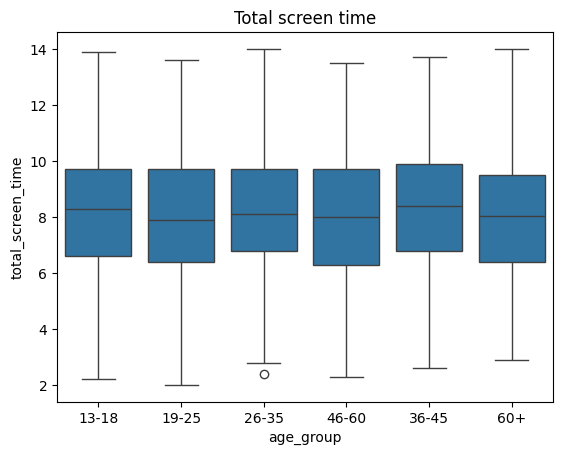

In [10]:
sns.boxplot(data=df,x='age_group',y='total_screen_time')
plt.title('Total screen time')
plt.show()

we see how our total screen time data is distributed by age groups 

In [11]:
df['resting time']=df.entertainment_hours+df.social_media_hours
df

,user_id,date,age,age_group,social_media_hours,work_or_study_hours,entertainment_hours,total_screen_time,primary_device,internet_type,resting time
0,1,2024-04-02,15,13-18,2.2,3.7,2.4,8.3,Mobile,WiFi,4.6
1,2,2024-06-07,13,13-18,1.1,6.9,2.1,10.1,Tablet,WiFi,3.2
2,3,2024-04-03,21,19-25,1.3,5.7,1.6,8.6,Tablet,WiFi,2.9
3,4,2024-10-02,35,26-35,2.5,5.0,2.0,9.5,Mobile,WiFi,4.5
4,5,2024-10-05,49,46-60,0.2,6.3,2.8,9.3,Laptop,WiFi,3.0
...,...,...,...,...,...,...,...,...,...,...,...
2795,2796,2024-11-19,33,26-35,3.2,2.6,1.2,7.0,Mobile,Mobile Data,4.4
2796,2797,2024-06-24,52,46-60,2.1,1.2,3.0,6.3,Mobile,WiFi,5.1
2797,2798,2024-03-11,21,19-25,1.2,6.0,0.7,7.9,Mobile,Mobile Data,1.9
2798,2799,2024-12-30,20,19-25,2.2,6.4,1.6,10.2,Mobile,WiFi,3.8


We created ne column named 'resting time' which shows the person's spending time on internet for resting(not working or studying)

In [12]:
df.dtypes

user_id                  int64
date                       str
age                      int64
age_group                  str
social_media_hours     float64
work_or_study_hours    float64
entertainment_hours    float64
total_screen_time      float64
primary_device             str
internet_type              str
resting time           float64
dtype: object

We see that our date column's dtype is str, and type of primary device is str.

In [13]:
df.date=pd.to_datetime(df.date)
df.primary_device=df['primary_device'].astype('category')
df.dtypes

user_id                         int64
date                   datetime64[us]
age                             int64
age_group                         str
social_media_hours            float64
work_or_study_hours           float64
entertainment_hours           float64
total_screen_time             float64
primary_device               category
internet_type                     str
resting time                  float64
dtype: object

We changed type of date column to datetime type and type of primary device to category type.

# Step 3

1. How does the average total_screen_time vary across different age_group categories?

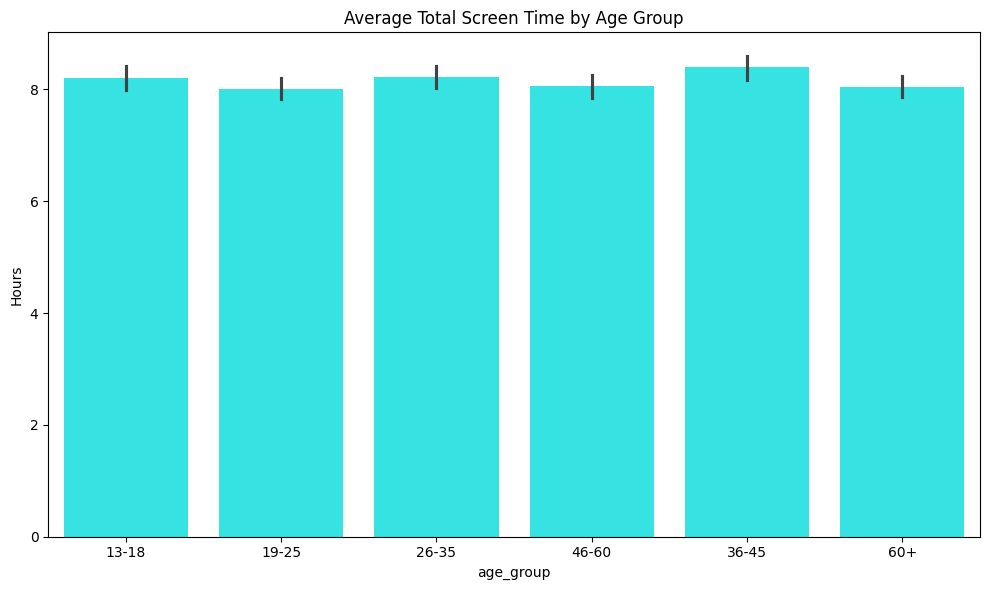

In [14]:
plt.figure(figsize=(10,6))
sns.barplot(data=df,x='age_group',y='total_screen_time', color='cyan',alpha=0.9)
plt.title('Average Total Screen Time by Age Group')
plt.ylabel('Hours')
plt.tight_layout()
plt.show()

2. Is there a correlation between social_media_hours and work_or_study_hours?

Correlation: -0.01


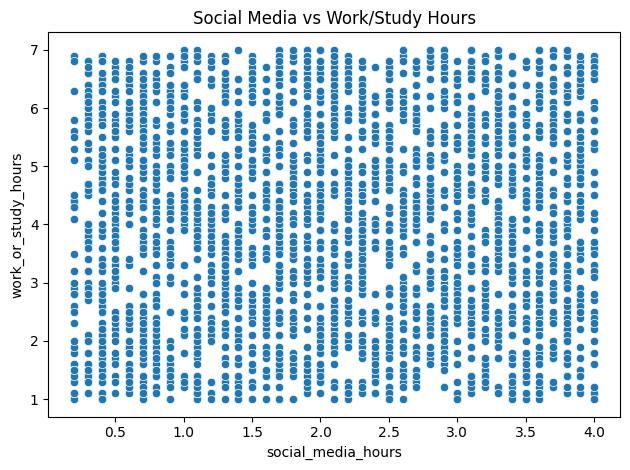

In [15]:
correlation = df['social_media_hours'].corr(df['work_or_study_hours'])
print(f"Correlation: {correlation:.2f}")
sns.scatterplot(data=df,x='social_media_hours',y='work_or_study_hours')
plt.title('Social Media vs Work/Study Hours')
plt.tight_layout()
plt.show()


We can observe both from the answer and the plot that there is no linear relationship between them.

3. Which primary_device is associated with the highest average entertainment_hours?

In [16]:
device_ent=df.groupby('primary_device')['entertainment_hours'].mean().sort_values(ascending=False)
print(device_ent)
print('\n')
print(device_ent.head(1))

primary_device
Tablet    2.031507
Mobile    2.020973
Laptop    2.013067
Name: entertainment_hours, dtype: float64


primary_device
Tablet    2.031507
Name: entertainment_hours, dtype: float64


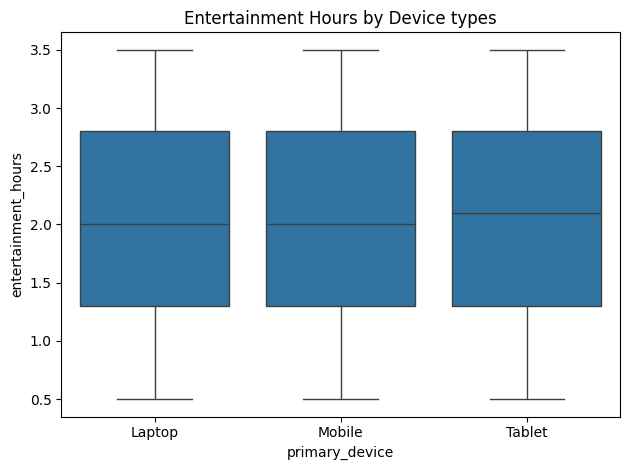

In [17]:
sns.boxplot(data=df,x='primary_device',y='entertainment_hours')
plt.title('Entertainment Hours by Device types')
plt.tight_layout()
plt.show()

4. Does the internet_type significantly affect the total_screen_time of users?

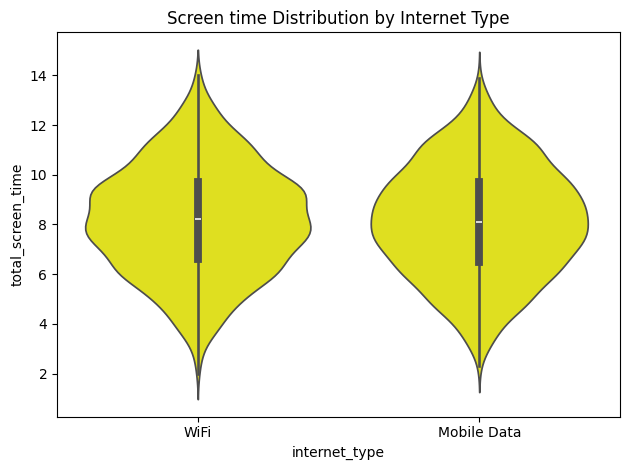

In [18]:
sns.violinplot(data=df,x='internet_type',y='total_screen_time',color='yellow')
plt.title('Screen time Distribution by Internet Type')
plt.tight_layout()
plt.show()

5. Is there a relationship between total_screen_time and resting time?

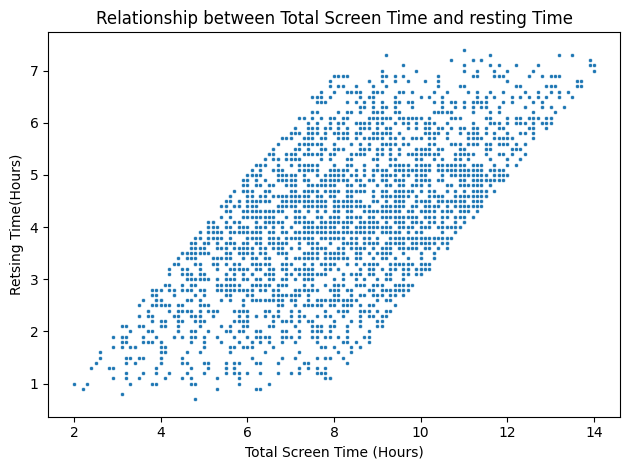

In [19]:
sns.scatterplot(data=df,x='total_screen_time',y='resting time',marker='.')
plt.title('Relationship between Total Screen Time and resting Time')
plt.xlabel('Total Screen Time (Hours)')
plt.ylabel('Retsing Time(Hours)')
plt.tight_layout()
plt.show()

We see that the relationship between Total Screen Time and Resting time is positive.

6. How does the average total_screen_time change over the observed date period?

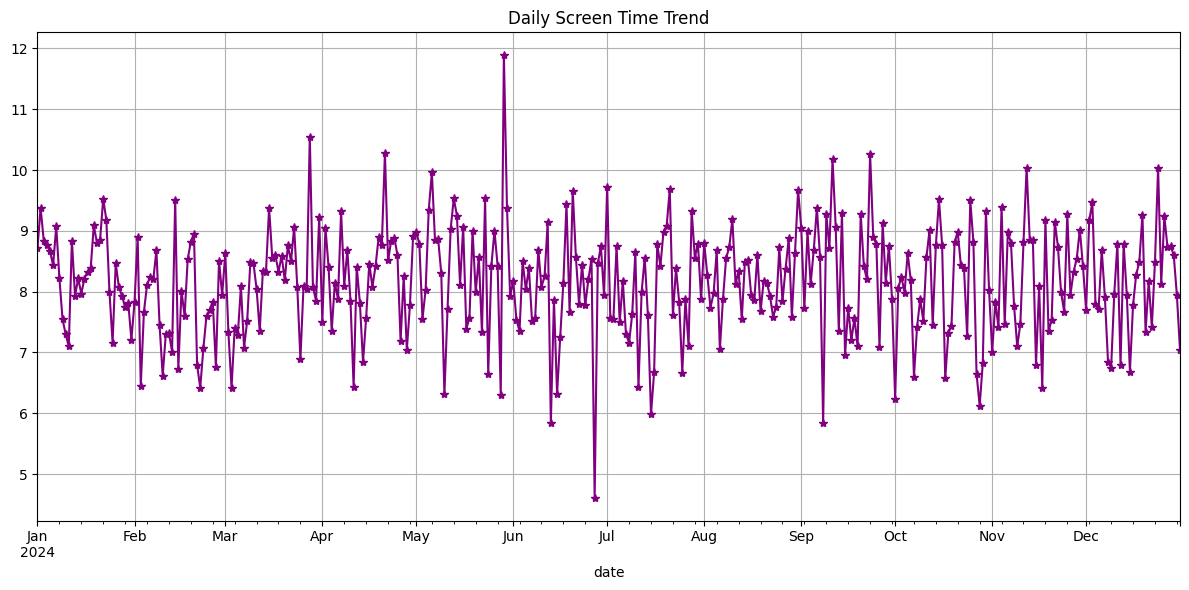

In [20]:
daily_trend=df.groupby('date')['total_screen_time'].mean()
plt.figure(figsize=(12,6))
daily_trend.plot(kind='line',marker='*',color='purple')
plt.title('Daily Screen Time Trend')
plt.grid(True)
plt.tight_layout()
plt.show()

7. What is the most common primary_device for each age_group?

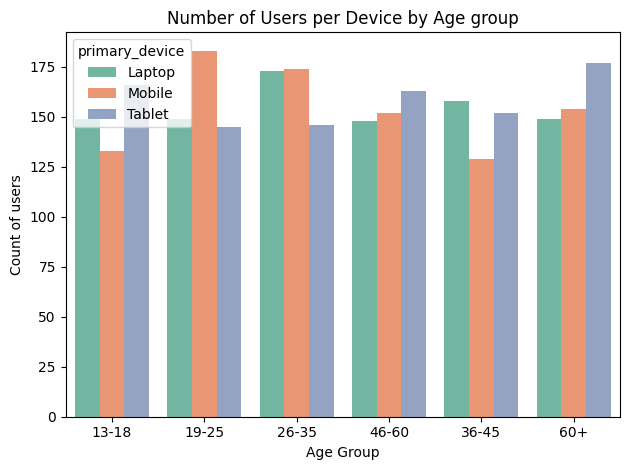

In [21]:
sns.countplot(data=df,x='age_group', hue='primary_device',palette='Set2')
plt.title('Number of Users per Device by Age group')
plt.ylabel('Count of users')
plt.xlabel('Age Group')
plt.tight_layout()
plt.show()

# Step 4 Visualization Part

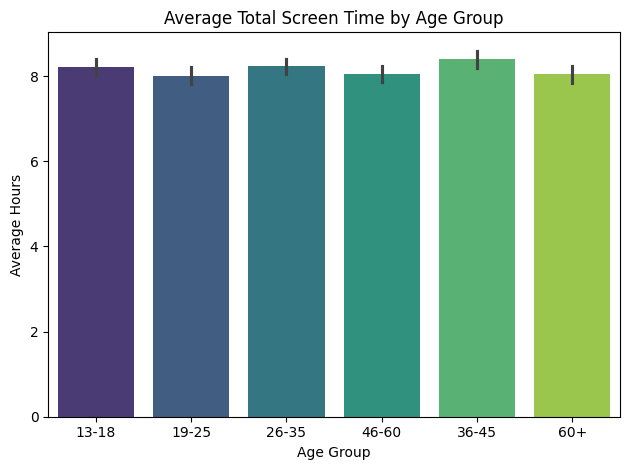

In [22]:
#                                       Bar Chart
# Total screen Hours by Age Groups
sns.barplot(data=df,x='age_group',y='total_screen_time',hue='age_group',palette='viridis')
plt.title('Average Total Screen Time by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Hours')
plt.tight_layout()
plt.show()



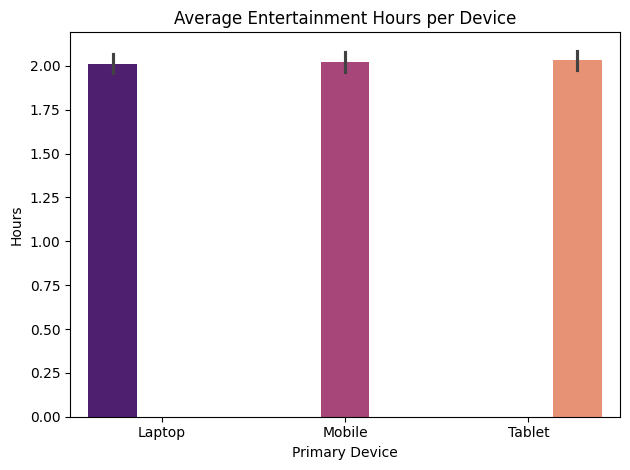

In [23]:
#                          Bar Chart
#Distribution of Entertainment Hours by Primary Device

sns.barplot(data=df, x='primary_device',y='entertainment_hours',hue='primary_device',palette='magma')
plt.title('Average Entertainment Hours per Device')
plt.xlabel('Primary Device')
plt.ylabel('Hours')
plt.tight_layout()
plt.show()

We see that average entertainment hours per device approximately same.

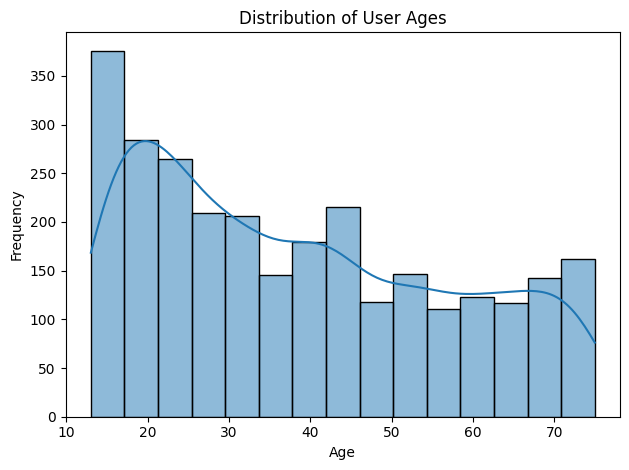

In [24]:
# Distributions of users' age          (Histogram)

sns.histplot(data=df,x='age',bins=15,kde=True)
plt.title('Distribution of User Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

We see here count of the users by their ages.

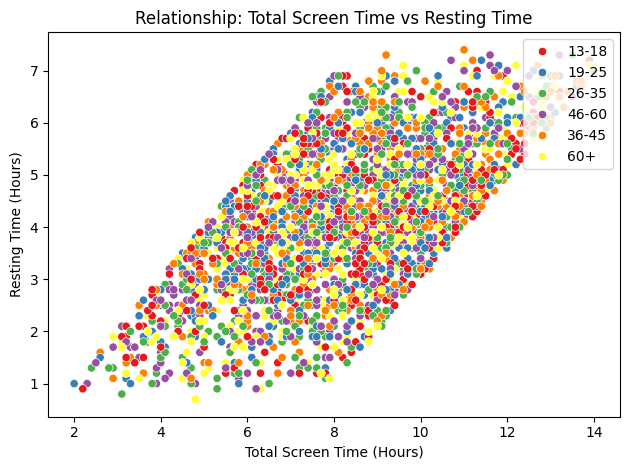

In [25]:
#                                                                     Scatter Plot
# how resting time changes when total screen time increse 
sns.scatterplot(data=df,x='total_screen_time',y='resting time',hue='age_group',palette='Set1')
plt.title('Relationship: Total Screen Time vs Resting Time')
plt.xlabel('Total Screen Time (Hours)')
plt.ylabel('Resting Time (Hours)')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

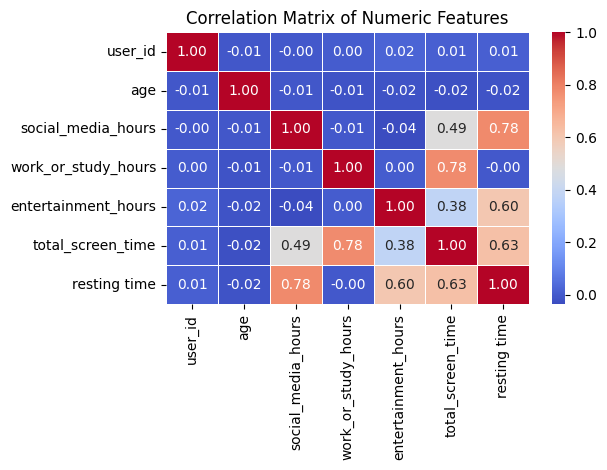

In [26]:
#                                    HeatMap
#Correlation between data's numeric values
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

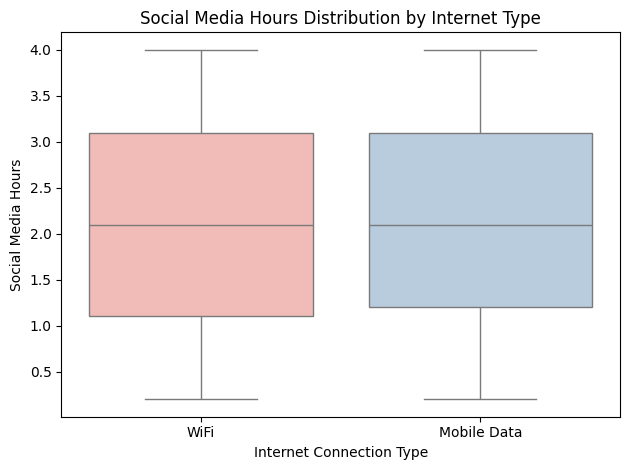

In [27]:
#                                      Box Plot
# Social Media Hours according to Internet types
sns.boxplot(data=df,x='internet_type',y='social_media_hours',hue='internet_type',palette='Pastel1')
plt.title('Social Media Hours Distribution by Internet Type')
plt.xlabel('Internet Connection Type')
plt.ylabel('Social Media Hours')
plt.tight_layout()
plt.show()

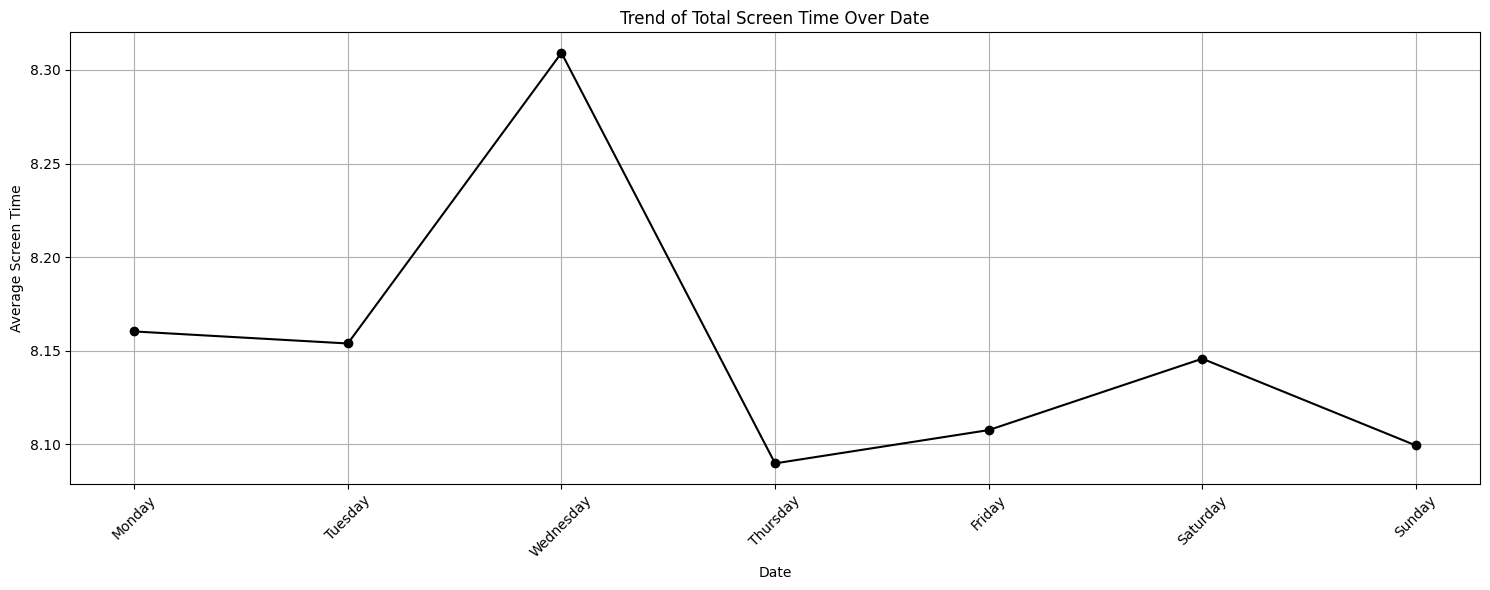

In [28]:
#                                   Line Graph
# Total screen Time Over days


df['date'] = pd.to_datetime(df['date']) # changed type to datetime
df['weekday'] = df['date'].dt.day_name() # created new column named 'week_day'
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'] # create a list with week days logic
weekday_trend = df.groupby('weekday')['total_screen_time'].mean().reindex(days_order) # created weekday_trend (calculating average total screen time by weekdays )
# and orders this from monday to sunday
plt.figure(figsize=(15,6))
weekday_trend.plot(kind='line', marker='o', color='black')
plt.title('Trend of Total Screen Time Over Date')
plt.xlabel('Date')
plt.ylabel('Average Screen Time')
plt.xticks(rotation=45) # 45degree rotation at x labels
plt.grid(True)
plt.tight_layout() # more accurate graph
plt.show()

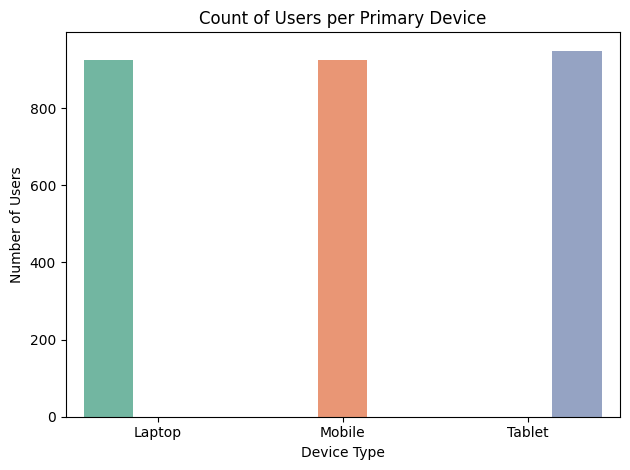

In [29]:
#                             CountPlot
# How many devices per type
sns.countplot(data=df,x='primary_device',hue='primary_device',palette='Set2')
plt.title('Count of Users per Primary Device')
plt.xlabel('Device Type')
plt.ylabel('Number of Users')
plt.tight_layout()
plt.show()

# Step 5      Statistical Analysis

In [30]:
df.describe()

,user_id,date,age,social_media_hours,work_or_study_hours,entertainment_hours,total_screen_time,resting time
count,2800.000000,2800,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000
mean,1400.500000,2024-06-30 08:12:10.285714,38.397500,2.117143,4.016107,2.021929,8.155179,4.139071
min,1.000000,2024-01-01 00:00:00,13.000000,0.200000,1.000000,0.500000,2.000000,0.700000
25%,700.750000,2024-03-30 00:00:00,22.000000,1.100000,2.500000,1.300000,6.600000,3.200000
50%,1400.500000,2024-07-02 00:00:00,35.000000,2.100000,4.000000,2.000000,8.100000,4.200000
75%,2100.250000,2024-09-30 00:00:00,53.000000,3.100000,5.500000,2.800000,9.700000,5.100000
max,2800.000000,2024-12-31 00:00:00,75.000000,4.000000,7.000000,3.500000,14.000000,7.400000
std,808.434702,NaN,18.436556,1.113908,1.722615,0.876120,2.211885,1.392860


here, We show count, mean,min,25%,50%,75% , max and standdard deviations for each column. 

In [31]:
print(f'Average age: {df.age.mean()}')
print(f'Maximum Sosial Media Hours: {df.social_media_hours.max()}')
print(f'Standard deviation of total screen times: {df.total_screen_time.std()}')
print(f'Median of Entertainment hours: {df.entertainment_hours.median()}')
print(f'Minimum hours of Resting Time: {df['resting time'].min()}')
print(f'Mode(most repeated) of Ages: {df.age.mode()[0]}') # we wrote [0] here because mode function always return answer as a series

Average age: 38.3975
Maximum Sosial Media Hours: 4.0
Standard deviation of total screen times: 2.2118848899169787
Median of Entertainment hours: 2.0
Minimum hours of Resting Time: 0.7
Mode(most repeated) of Ages: 17


In [32]:
df.groupby('age_group').agg(
    Total=('total_screen_time','sum'),
    Average=('resting time','mean'),
    Counts=('age','count')
)
# We just find total sum of 'total screen time', mean of 'resting time' hours and Count of users(by counting ages column) FOR EACH AGE GROUP


,Total,Average,Counts
age_group,,,
13-18,3678.1,4.139509,448
19-25,3820.8,4.105660,477
26-35,4057.2,4.136714,493
36-45,3684.3,4.328702,439
46-60,3731.5,4.077322,463
60+,3862.6,4.060417,480


In [33]:
df.date=pd.to_datetime(df.date)
df['months']=df['date'].dt.month_name()
new=df.groupby('months')['total_screen_time'].sum()
print(new)

# we just find sum of 'total screen time' per each Month 

months
April        1779.6
August       2111.4
December     1888.3
February     1878.4
January      2088.7
July         1829.8
June         1775.6
March        1785.3
May          2010.1
November     1946.5
October      1820.9
September    1919.9
Name: total_screen_time, dtype: float64
